# Automated Barcoding Detection

Note to self: scriptify the manual line segment extraction, which may be useful

E2E file
→ select B-scan
→ obtain BM boundary
→ flatten to BM
→ crop fixed depth below BM
→ normalize ROI
→ return arrays + metadata

## E2E Prep, Flattening, and Cropping

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().resolve()

while not (PROJECT_ROOT / "src").exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise RuntimeError("Could not locate the project root.")
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.barcode.data import (
    inspect_volume_layers,
    load_e2e_volume,
    preprocess_bscan,
)

# Preprocessing settings
NORMALIZE = False

# Only used when NORMALIZE is True
LOWER_PERCENTILE = 1.0
UPPER_PERCENTILE = 99.0

DEPTH_BELOW_BM = 150

In [2]:
E2E_PATH = PROJECT_ROOT / "data" / "heyex" / "meta" / "ea8.E2E"

volume = load_e2e_volume(E2E_PATH)

print("Volume type:", type(volume))
print("Volume shape:", volume.shape)
print("Available layers:", inspect_volume_layers(volume))

Volume type: <class 'eyepy.core.eyevolume.EyeVolume'>
Volume shape: (97, 496, 512)
Available layers: ['ILM', 'BM', 'RNFL', 'GCL', 'IPL', 'INL', 'OPL', 'ELM', 'PR1', 'PR2', 'RPE']


In [3]:
# Select the central B-scan
NUM_BSCANS = len(volume)
BSCAN_INDEX = NUM_BSCANS // 2

bscan = volume[BSCAN_INDEX]

print(f"Number of B-scans: {NUM_BSCANS}")
print(f"Selected central B-scan: {BSCAN_INDEX}")
print(f"B-scan shape: {bscan.shape}")
print("Metadata:")
print(bscan.meta)

Number of B-scans: 97
Selected central B-scan: 48
B-scan shape: (496, 512)
Metadata:
start_pos: (-9.757146835327148, -0.48019957542419434)
end_pos: (10.255987167358398, 0.16282153129577637)
pos_unit: °
unknown0: 23
size_y: 496
size_x: 512
start_x: -9.757146835327148
start_y: -0.48019957542419434
end_x: 10.255987167358398
end_y: 0.16282153129577637
zero1: 0
unknown1: 48280460.0
scale_y: 0.0038716699928045273
unknown2: 1.0
zero2: 0
unknown3: ListContainer: 
    5987.3955078125
    117.92044830322266
zero3: 0
imgSizeWidth: 511
n_bscans: 97
aktImage: 48
scan_pattern: 1
center_x: 0.249420166015625
center_y: -0.15868902206420898
unknown4: 1
acquisitionTime: 2024-02-16T23:22:37.164000
numAve: 0
quality: 0.8416000008583069
unknown5: 0.9146999716758728


In [4]:
processed = preprocess_bscan(
    volume=volume,
    bscan_index=BSCAN_INDEX,
    bm_layer_name="BM",
    depth_below_bm=DEPTH_BELOW_BM,
    normalize=NORMALIZE,
    lower_percentile=LOWER_PERCENTILE,
    upper_percentile=UPPER_PERCENTILE,
)

print("Raw shape:", processed.raw_bscan.shape)
print("BM boundary shape:", processed.bm_boundary.shape)
print("Flattened shape:", processed.flattened_bscan.shape)
print("Sub-BM crop shape:", processed.sub_bm_crop.shape)
print("Reference row:", processed.reference_row)
print("Normalization enabled:", processed.normalization_enabled)

if processed.normalization_enabled:
    print(
        "Normalization percentiles:",
        processed.lower_percentile,
        processed.upper_percentile,
    )

Raw shape: (496, 512)
BM boundary shape: (512,)
Flattened shape: (496, 512)
Sub-BM crop shape: (150, 512)
Reference row: 255
Normalization enabled: False


In [5]:
print("BM minimum row:", processed.bm_boundary.min())
print("BM maximum row:", processed.bm_boundary.max())
print("BM median row:", np.median(processed.bm_boundary))
print("First 10 coordinates:", processed.bm_boundary[:10])

BM minimum row: 211.09372
BM maximum row: 283.43945
BM median row: 255.50412
First 10 coordinates: [222.61269 222.87262 223.13268 223.393   223.65387 223.91563 224.17873
 224.44365 224.71101 224.98146]


In [6]:
bm_layer = volume.layers["BM"]

print("Type:", type(bm_layer))
print("Attributes:", [name for name in dir(bm_layer) if not name.startswith("_")])

if hasattr(bm_layer, "data"):
    print("Data type:", type(bm_layer.data))
    print("Data shape:", np.asarray(bm_layer.data).shape)

Type: <class 'eyepy.core.annotations.EyeVolumeLayerAnnotation'>
Attributes: ['data', 'knots', 'layer_indices', 'meta', 'name', 'volume']
Data type: <class 'numpy.ndarray'>
Data shape: (97, 512)


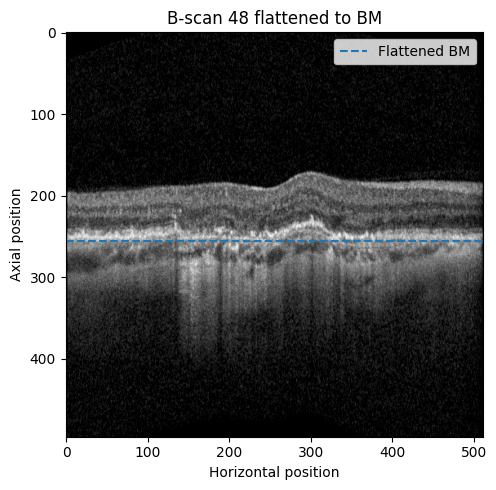

In [7]:
# Flattened scan
plt.figure(figsize=(12, 5))

plt.imshow(
    processed.flattened_bscan,
    cmap="gray",
)

plt.axhline(
    processed.reference_row,
    linestyle="--",
    linewidth=1.5,
    label="Flattened BM",
)

plt.title(f"B-scan {processed.bscan_index} flattened to BM")
plt.xlabel("Horizontal position")
plt.ylabel("Axial position")
plt.legend()
plt.tight_layout()
plt.show()

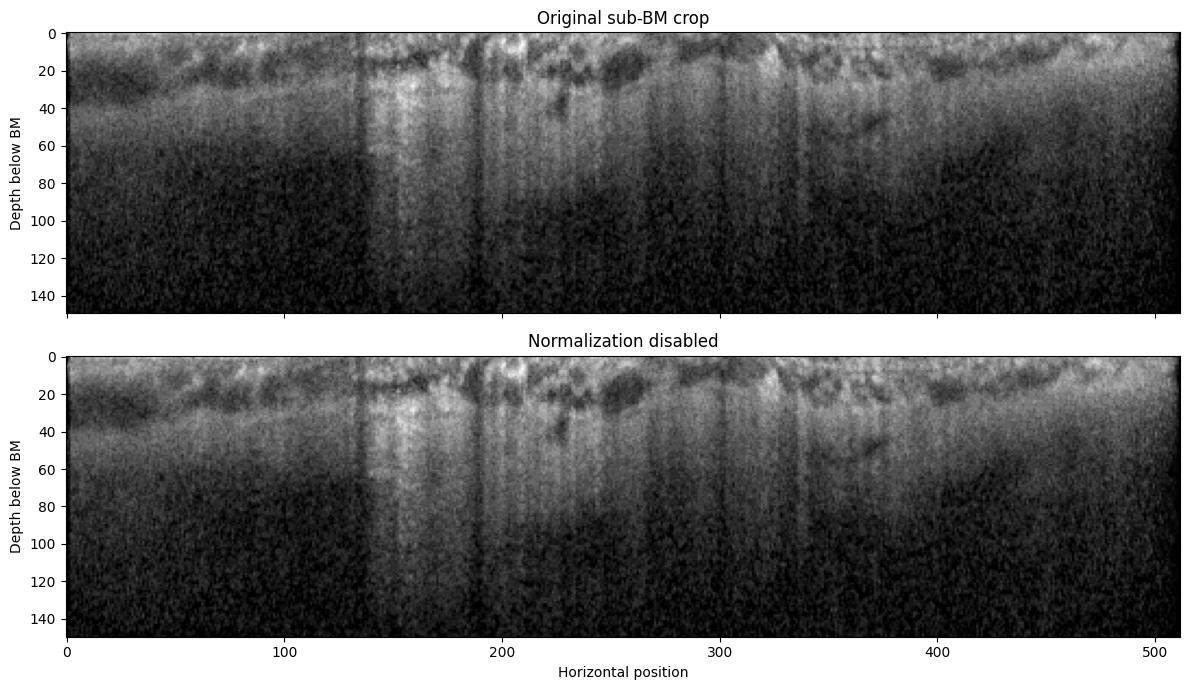

In [8]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(12, 7),
    sharex=True,
)

axes[0].imshow(
    processed.sub_bm_crop,
    cmap="gray",
    aspect="auto",
)

axes[0].set_title("Original sub-BM crop")
axes[0].set_ylabel("Depth below BM")

axes[1].imshow(
    processed.normalized_crop,
    cmap="gray",
    aspect="auto",
)

if processed.normalization_enabled:
    axes[1].set_title(
        "Normalized sub-BM crop "
        f"({processed.lower_percentile:g}–"
        f"{processed.upper_percentile:g} percentiles)"
    )
else:
    axes[1].set_title(
        "Normalization disabled"
    )

axes[1].set_xlabel("Horizontal position")
axes[1].set_ylabel("Depth below BM")

plt.tight_layout()
plt.show()

I actually suspect vertical persistence is going to end up being the key feature rather than brightness. The human eye is picking up those long, coherent bright columns—not just bright spots—and our algorithm should try to quantify exactly that. That also aligns well with the paper you’re using as inspiration: reduce the OCT to a robust 1D signal along the horizontal axis, segment contiguous abnormal regions, and then perform all measurements within those detected intervals.

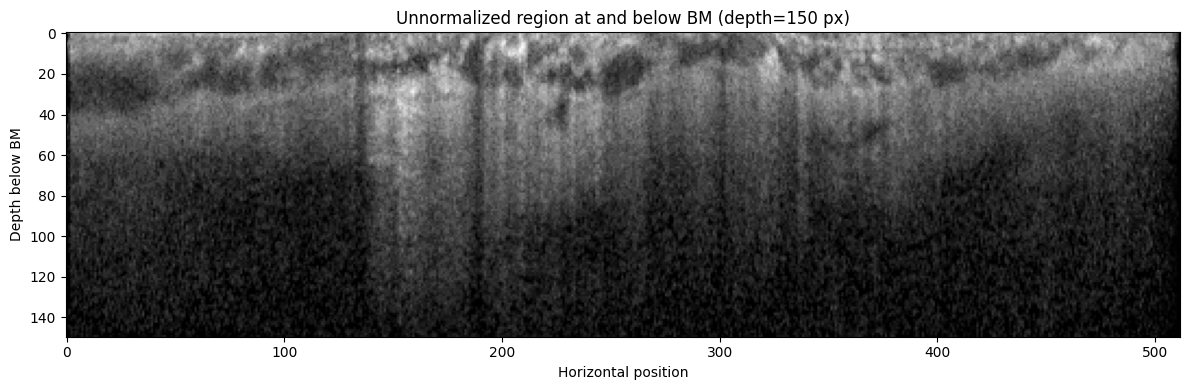

In [9]:
# Region below BM
plt.figure(figsize=(12, 4))

plt.imshow(
    processed.normalized_crop,
    cmap="gray",
    aspect="auto",
)

if processed.normalization_enabled:
    title = (
        f"Normalized region at and below BM "
        f"(depth={processed.depth_below_bm} px, "
        f"percentiles={processed.lower_percentile:g}–"
        f"{processed.upper_percentile:g})"
    )
else:
    title = (
        f"Unnormalized region at and below BM "
        f"(depth={processed.depth_below_bm} px)"
    )

plt.title(title)
plt.xlabel("Horizontal position")
plt.ylabel("Depth below BM")
plt.tight_layout()
plt.show()

## Barcode Detection Tuning

* Implement ImageJ-like profile, where a line segment is made on the processed scan and the intensity is extracted
* Should have arguments for:
    * start: Where the line segment starts (default: 73, 135)
    * depth: How far below the top the starting point is
    * end: Where the line ends (default: 1169, 135)
    * stepsize: How many pixels each measurement is taken (default: 1 px)
    * plot: whether plot is saved or not (default: True)
    * data: Whether numerical data is extracted or not (default: True)
* The plot should be have gray scale values of 0-300 so regardless of the scan, the axis scale the same
* Should be able to take in a bscan


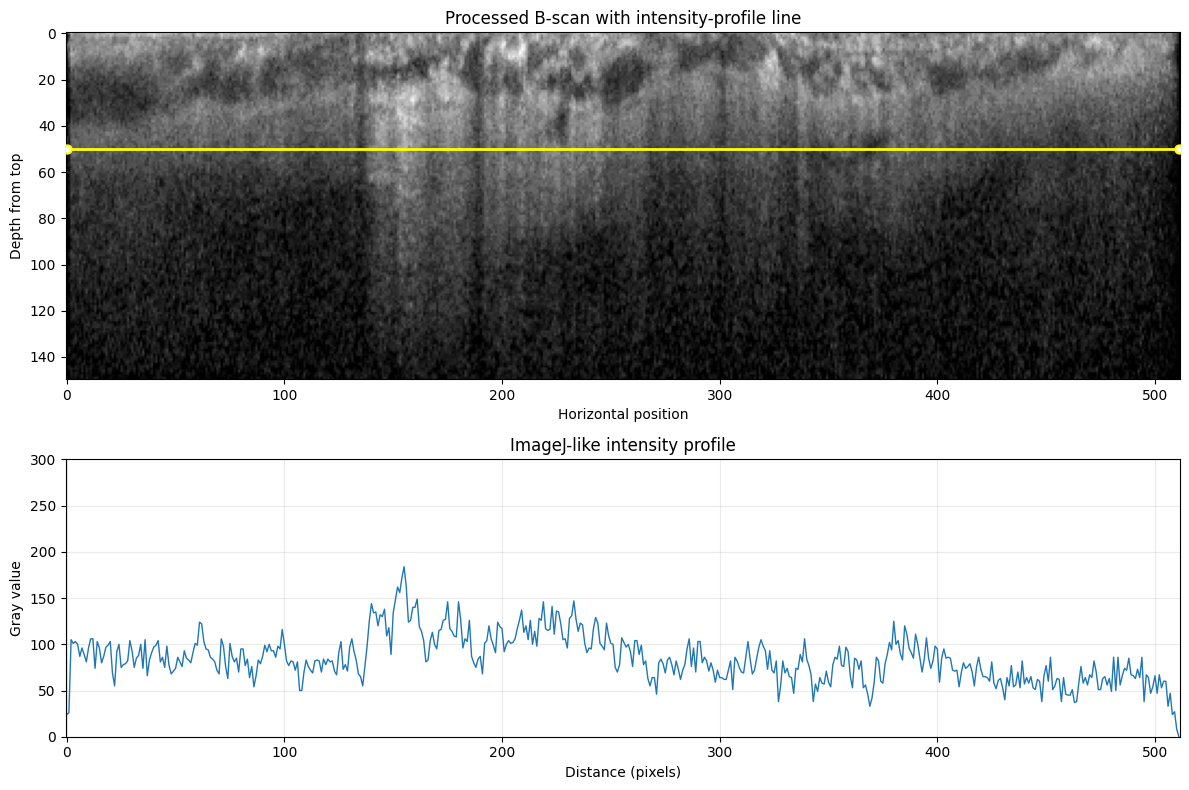

In [ ]:
from src.barcode.model_threshold import extract_intensity_profile

PROFILE_DEPTH = 50

profile = extract_intensity_profile(
    bscan=processed.normalized_crop,
    start=(0, PROFILE_DEPTH),
    depth=PROFILE_DEPTH,
    end=(processed.normalized_crop.shape[1] - 1, PROFILE_DEPTH),
    stepsize=1, #2*pixel
    plot=True,
    data=True,
    #     plot_path=PROJECT_ROOT / "results" / "profile_plot.png",
    #     data_path=PROJECT_ROOT / "results" / "profile_values.csv",
)

plt.show()

* Normaliza around the selected line instead of the whole scan, or average along PROFILE_DEPTH, +-2, +-4
* Overlay the profile plot onto the processed scan, and add marking utilities for manual marking of Barcoding, EA, and normal
* Do a series of sensitivity tests like different normalization values, different margins, and different stepsizes

In [13]:
print(profile.profile_data.shape)
print(profile.profile_data[:10])

(512, 2)
[[  0.  24.]
 [  1.  26.]
 [  2. 105.]
 [  3. 101.]
 [  4. 103.]
 [  5. 100.]
 [  6.  87.]
 [  7.  96.]
 [  8.  89.]
 [  9.  81.]]


## Evaluation


## Measurement Extraction